### GANs

In [3]:
from keras.datasets import mnist

# Load and prepare MNIST dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_valid = X_test.astype('float32') / 255.0

-The chess memory experiment and a simple autoencoder
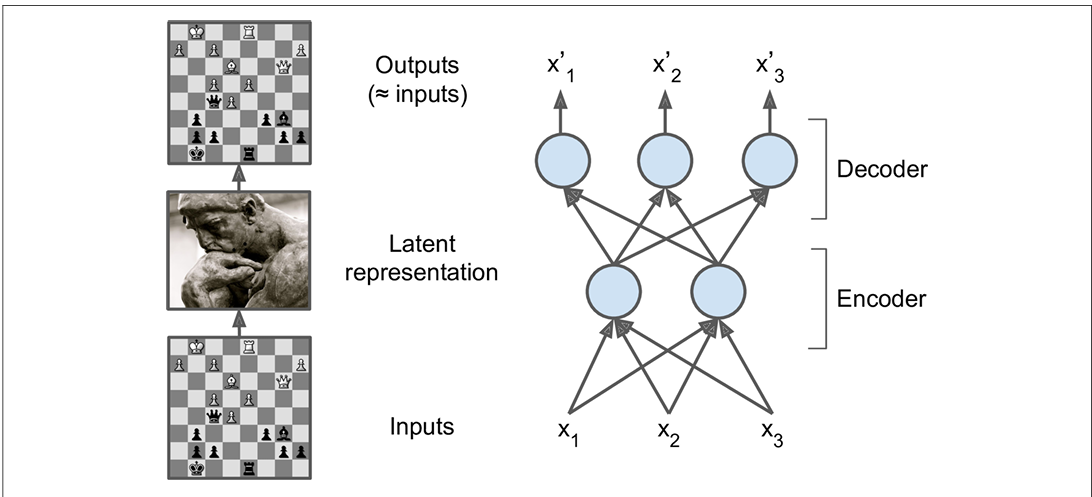

##### Perfoming PCA with an Undercomplete Linear Autoencoder

In [2]:
import tensorflow as tf
import numpy as np 
import keras
encoder = keras.models.Sequential([keras.layers.Dense(2 , input_shape=[3])])
decoder = keras.models.Sequential([keras.layers.Dense(3, input_shape=[2])])
autoencoder = keras.models.Sequential([encoder,decoder])

autoencoder.compile(loss='mse', optimizer=keras.optimizers.SGD(learning_rate=0.1))

c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
history = autoencoder.fit(X_train ,X_train ,epochs = 20)

Epoch 1/20


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 28, 28), dtype=float32) with name 'keras_tensor_11' and path ''. Expected shape (None, 3), but input has incompatible shape (32, 28, 28)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 28, 28), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

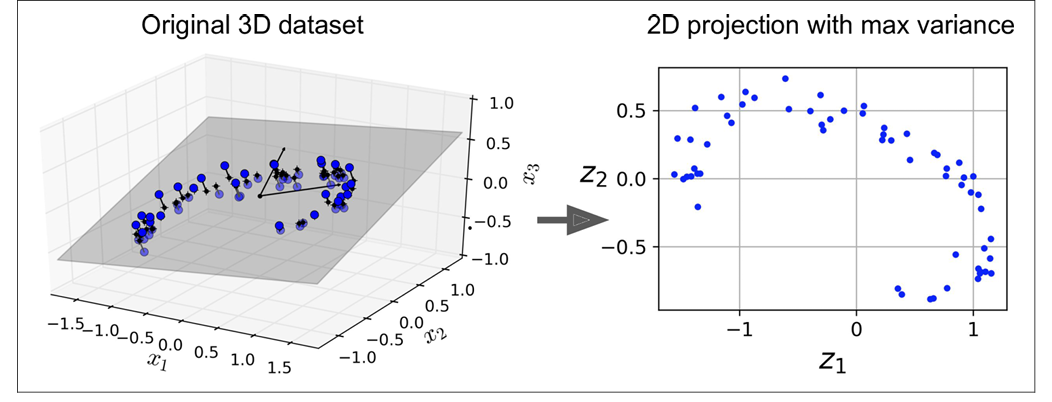

### Stacked Autoencoders

-Adding more layers helps the autoencoder learn more complex codings 
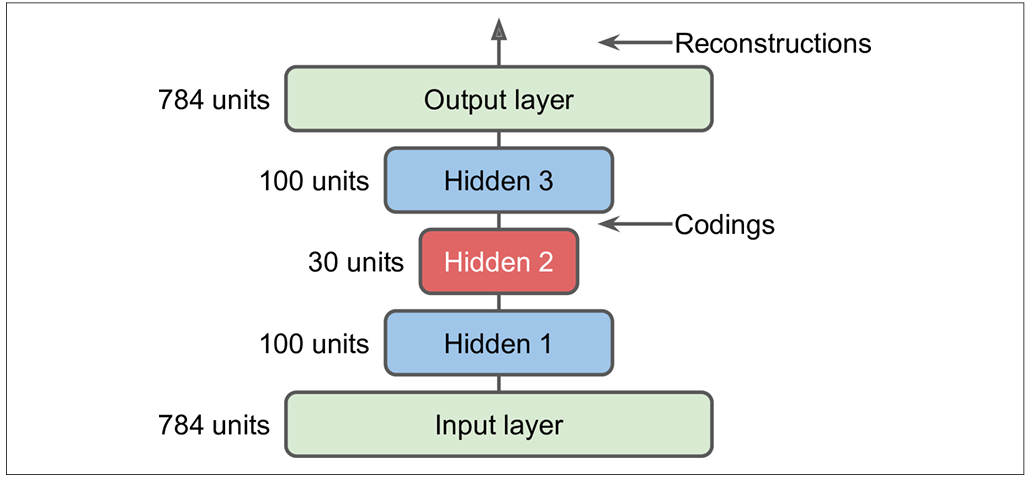

In [5]:
stacked_encoder = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(100, activation='selu'),
    keras.layers.Dense(30, activation='selu'),

])

stacked_decoder = keras.models.Sequential([
    keras.layers.Dense(100, activation='selu', input_shape=[30]),
    keras.layers.Dense(28 * 28, activation='sigmoid'),
    keras.layers.Reshape((28, 28))
])

stacked_ae =keras.models.Sequential([stacked_encoder, stacked_decoder])
stacked_ae.compile(loss='binary_crossentropy', optimizer=keras.optimizers.SGD(learning_rate=1.5))

history = stacked_ae.fit(X_train, X_train, epochs=10,validation_data=[X_valid, X_valid])


Epoch 1/10


c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1790 - val_loss: 0.1369
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1290 - val_loss: 0.1211
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1185 - val_loss: 0.1130
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1134 - val_loss: 0.1096
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1105 - val_loss: 0.1070
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1081 - val_loss: 0.1050
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1062 - val_loss: 0.1097
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1047 - val_loss: 0.1029
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1028 - val_loss: 0.1005
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1014 - val_loss: 0.0997


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


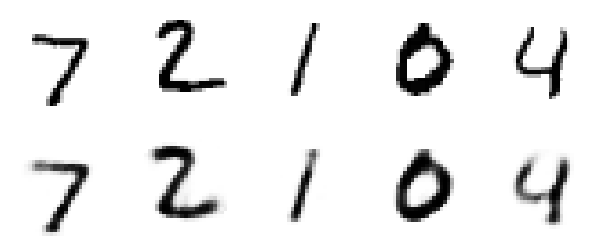

In [6]:
import matplotlib.pyplot as plt

def plot_image(image):
    plt.imshow(image, cmap="binary")
    plt.axis("off")

def show_reconstructions(model, n_images=5):
    reconstructions = model.predict(X_valid[:n_images])
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plot_image(X_valid[image_index])
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plot_image(reconstructions[image_index])
    plt.show()

show_reconstructions(stacked_ae)

In [7]:
from sklearn.manifold import TSNE
X_valid_compressed = stacked_encoder.predict(X_valid)
tsne = TSNE()
X_valid_2D = tsne.fit_transform(X_valid_compressed)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step


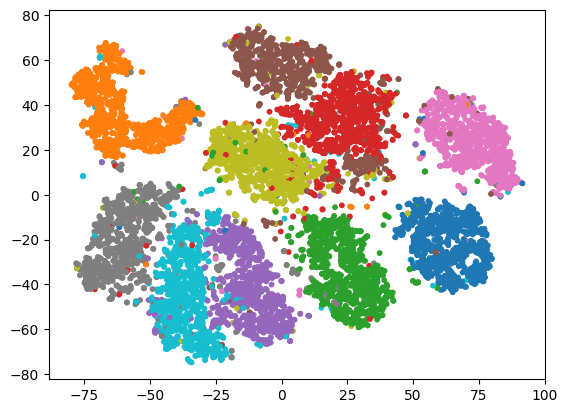

In [9]:
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_test, s=10, cmap="tab10")

#### Tying Weights



In [ ]:
class DenseTranspose(keras.layers.Layer):
    def __init__(self, dense, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.dense = dense
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        self.biases = self.add_weight(
            name="bias",
            initializer="zeros",
            shape=[self.dense.input_shape[-1]]
        )
        super().build(input_shape)

    def call(self, inputs):
        z = tf.matmul(inputs, self.dense.weights[0], transpose_b=True)
        return self.activation(z + self.biases)

In [ ]:
dense_1 = keras.layers.Dense(100,activation='selu')
dense_2 = keras.layers.Dense(30, activation='selu')
tied_encoder = keras.models.Sequential([    keras.layers.Flatten(input_shape=[28, 28]),
    dense_1, 
    dense_2
])

tied_decoder = keras.models.Sequential([
    DenseTranspose(dense_2, activation='selu'),
    DenseTranspose(dense_1, activation='sigmoid'),
    keras.layers.Reshape((28, 28))
])

tied_ae = keras.models.Sequential([tied_encoder, tied_decoder])

#### Convolutional Autoencoders

-The encoder is a regular CNN  composed of convolutional layers and pooling layers .It typically reduces the spatial dimensionality of the inputs while increasing the depth

In [ ]:
conv_encoder = keras.models.Sequential([
keras.layers.Reshape([28, 28, 1], input_shape=[28, 28]),
keras.layers.Conv2D(16, kernel_size=3, padding="same", activation="selu"),
keras.layers.MaxPool2D(pool_size=2),
keras.layers.Conv2D(32, kernel_size=3, padding="same", activation="selu"),
keras.layers.MaxPool2D(pool_size=2),
keras.layers.Conv2D(64, kernel_size=3, padding="same", activation="selu"),
keras.layers.MaxPool2D(pool_size=2)
])

conv_decoder = keras.models.Sequential([

    keras.layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding="same", activation="selu", input_shape=[4, 4, 64]),
    keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="same", activation="selu"),
    keras.layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding="same", activation="selu"),
    keras.layers.Conv2DTranspose(1, kernel_size=3, strides=1, padding="same", activation="sigmoid"),
     keras.layers.Reshape([28, 28])
])

### Recurrent Autoencoders 

-If you want to build an autoencoder for sequences , such as time series or text .The encoder is typically a sequence-to-vector RNN which compresses the input sequence down to a single vector .The decoder is a vector-to-sequence RNN that does the reverse.



In [ ]:
recurrent_encoder = keras.models.Sequential([
    keras.layers.LSTM(100, return_sequences=True, input_shape=[None, 28]),
    keras.layers.LSTM(30)
])
recurrent_decoder = keras.models.Sequential([
    keras.layers.RepeatVector(28, input_shape=[30]),
    keras.layers.LSTM(100, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(28, activation="sigmoid"))
])
recurrent_ae = keras.models.Sequential([recurrent_encoder, recurrent_decoder])

### Denoising Autoencoders

-Another way to force the autoencoder to learn useful features is to add noise to its inputs,the noise can be pure Gaussian

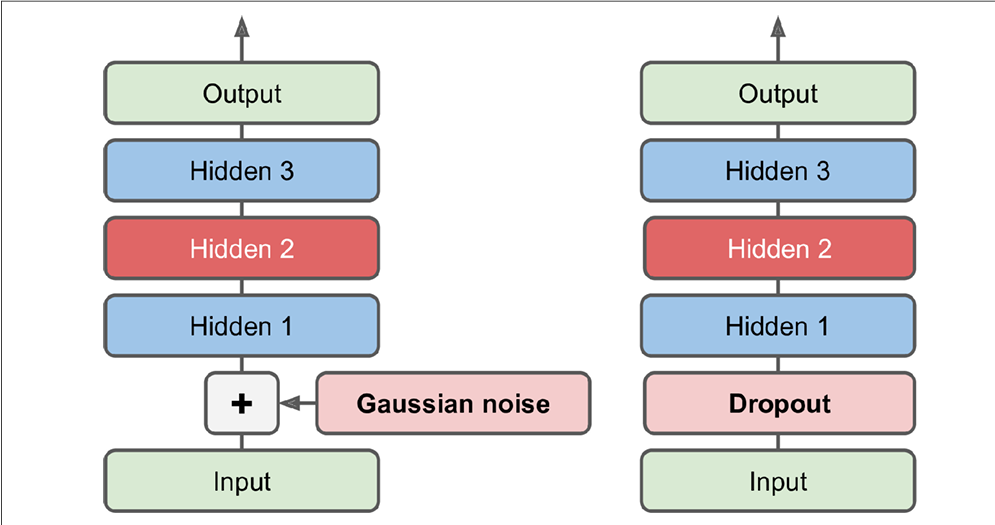

In [ ]:
dropout_encoder = keras.models.Sequential([
keras.layers.Flatten(input_shape=[28, 28]),
keras.layers.Dropout(0.5),
keras.layers.Dense(100, activation="selu"),
keras.layers.Dense(30, activation="selu")
])
dropout_decoder = keras.models.Sequential([
keras.layers.Dense(100, activation="selu", input_shape=[30]),
keras.layers.Dense(28 * 28, activation="sigmoid"),
keras.layers.Reshape([28, 28])
])
dropout_ae = keras.models.Sequential([dropout_encoder, dropout_decoder])

### Sparse Autoencoders

-Adding an appropiate term to hte cost fuction ,the autoencoder is pushed to reduce the number of active neurons in the coding layer .

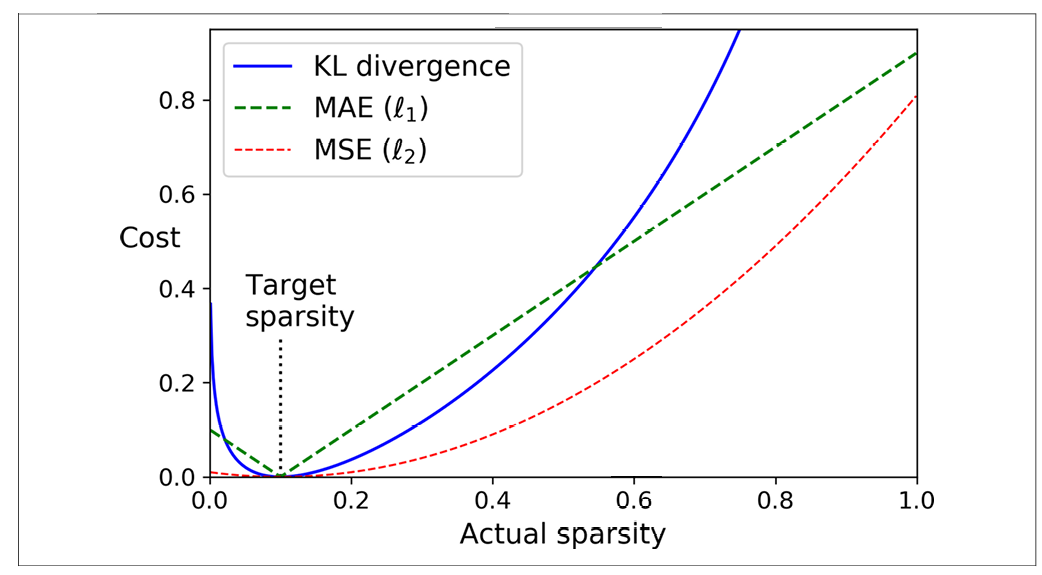

In [ ]:
# implemente a sparse autoencoder based on the KL divergence 

K = keras.backend
kl_divergence = keras.losses.kullback_leibler_divergence

class KLDivergenceRegularizer(keras.regularizers.Regularizer):
    def __init__(self, weight, target=0.1):
        self.weight = weight
        self.target = target

    def __call__(self, inputs):
        mean_activities = K.mean(inputs, axis=0)
        return self.weight * (
            kl_divergence(self.target, mean_activities) +
            kl_divergence(1.0 - self.target, 1.0 - mean_activities)
        )

    def get_config(self):
        return {"weight": self.weight, "target": self.target}

In [ ]:
kld_reg = KLDivergenceRegularizer(weight=0.05, target=0.1)
sparse_kl_encoder = keras.models.Sequential([
keras.layers.Flatten(input_shape=[28, 28]),
keras.layers.Dense(100, activation="selu"),
keras.layers.Dense(300, activation="sigmoid", activity_regularizer=kld_reg)
])
sparse_kl_decoder = keras.models.Sequential([
keras.layers.Dense(100, activation="selu", input_shape=[300]),
keras.layers.Dense(28 * 28, activation="sigmoid"),
keras.layers.Reshape([28, 28])
])
sparse_kl_ae = keras.models.Sequential([sparse_kl_encoder, sparse_kl_decoder])

### Varational Autoencoders

-they are probabilistic autoencoders ,meaning that their outputs are partly determined by chance ,even after training  ,they are generative autoencoders ,meaning that they can generate new instances that look like they were sampled from the training set.

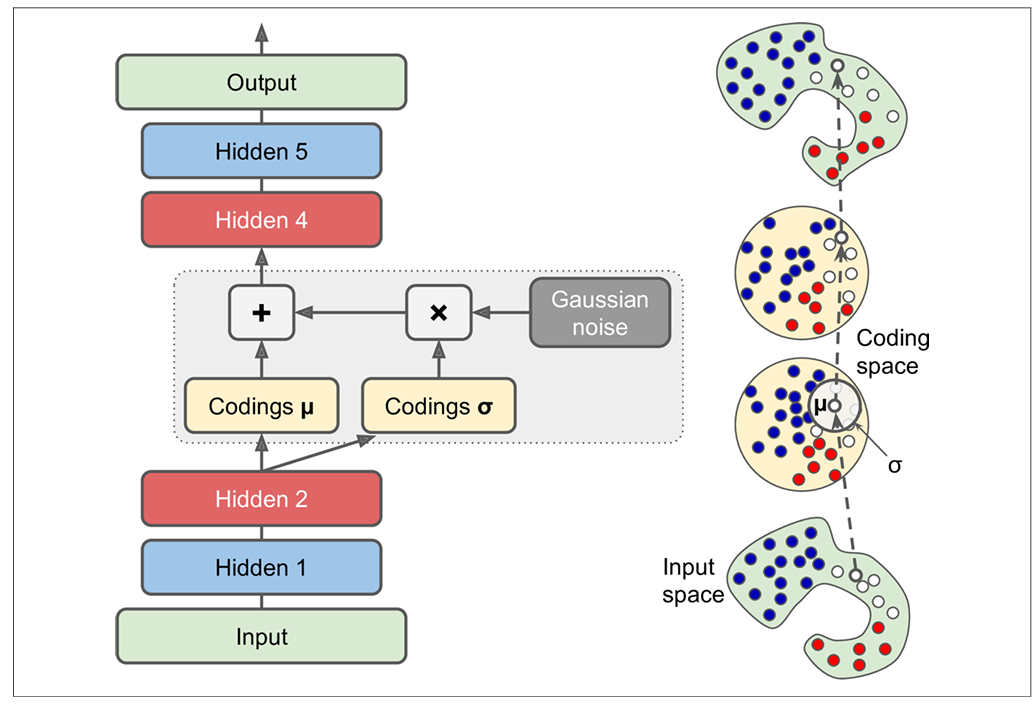

In [1]:
#create the encoder
#we will need a custom layer to sample the codings given u an y

class Sampling(keras.layers.Layer):
    def call(self, inputs):
        mean, log_var = inputs
        return K.random_normal(K.shape(log_var)) * K.exp(log_var / 2) + mean
codings_size = 10
inputs = keras.layers.Input(shape=[28, 28])
z = keras.layers.Flatten()(inputs)
z = keras.layers.Dense(150, activation="selu")(z)
z = keras.layers.Dense(100, activation="selu")(z)
codings_mean = keras.layers.Dense(codings_size)(z)  # μ
codings_log_var = keras.layers.Dense(codings_size)(z)  # γ
K = keras.backend
variational_encoder = keras.Model(
inputs=[inputs], outputs=[codings_mean, codings_log_var, codings])

NameError: name 'keras' is not defined

In [12]:
#build the decoder 
decoder_inputs = keras.layers.Input(shape=[codings_size])
x = keras.layers.Dense(100, activation="selu")(decoder_inputs)
x = keras.layers.Dense(150, activation="selu")(x)
x = keras.layers.Dense(28 * 28, activation="sigmoid")(x)
outputs = keras.layers.Reshape([28, 28])(x)
variational_decoder = keras.Model(inputs=[decoder_inputs], outputs=[outputs])


NameError: name 'codings_size' is not defined

In [ ]:
#build the variational autoencoder model
_, _, codings = variational_encoder(inputs)
reconstructions = variational_decoder(codings)
variational_ae = keras.Model(inputs=[inputs], outputs=[reconstructions])


In [ ]:
#We must add the latent loss and the reconstruction loss 
latent_loss = -0.5 * K.sum(
1 + codings_log_var - K.exp(codings_log_var) - K.square(codings_mean),
axis=-1)
variational_ae.add_loss(K.mean(latent_loss) / 784.)
variational_ae.compile(loss="binary_crossentropy", optimizer="rmsprop")


In [ ]:
#And finally we can train the autoencoder 

history = variational_ae.fit(X_train, X_train, epochs=50, batch_size=128, validation_data=[X_valid, X_valid])

### Generating Fashion MNIST Images

In [ ]:
codings =tf.ranndom.normal(shape=[12, codings_size])
images = variational_decoder(codings).numpy()

In [ ]:
#Use the decoder to produce all the images
codings_grid = tf.reshape(codings, [1, 3, 4, codings_size])
larger_grid = tf.image.resize(codings_grid, size=[5, 7])
interpolated_codings = tf.reshape(larger_grid, [-1, codings_size])
images = variational_decoder(interpolated_codings).numpy()


### Generative Adversial Networks - GANs

-Make neural networks compete against each other in the hope that this competition will push them to excel  ,GANs is composed of two neural networks : Generator and Discriminator

In [ ]:
#generator

codings_size = 30

generator = keras.models.Sequential([
    keras.layers.Dense(100, activation="selu", input_shape=[codings_size]),
    keras.layers.Dense(150, activation="selu"),
    keras.layers.Dense(28 * 28, activation="sigmoid"),
    keras.layers.Reshape([28, 28])

])


#discriminator


discriminator = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]), 
    keras.layers.Dense(150, activation="selu"),
    keras.layers.Dense(100, activation="selu"),
    keras.layers.Dense(1, activation="sigmoid")
])

gan = keras.models.Sequential([generator, discriminator])
discriminator.compile(loss="binary_crossentropy", optimizer="rmsprop")
discriminator.trainable = False
gan.compile(loss="binary_crossentropy", optimizer="rmsprop")

In [ ]:
batch_size = 32
dataset =tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000).batch(batch_size).prefetch(1)

In [ ]:
def train_gan(gan, dataset, batch_size, codings_size, n_epochs=50):
  generator, discriminator = gan.layers
  for epoch in range(n_epochs):
     for X_batch in dataset:
# phase 1 - training the discriminator
noise = tf.random.normal(shape=[batch_size, codings_size])
generated_images = generator(noise)
X_fake_and_real = tf.concat([generated_images, X_batch], axis=0)
y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
discriminator.trainable = True
discriminator.train_on_batch(X_fake_and_real, y1)
# phase 2 - training the generator
noise = tf.random.normal(shape=[batch_size, codings_size])
y2 = tf.constant([[1.]] * batch_size)
discriminator.trainable = False
gan.train_on_batch(noise, y2)
train_gan(gan, dataset, batch_size, codings_size)